# Apply babyseg to the OpenNeuro open dataset

In [ ]:
# The path to the data and where you want to save it. 
# We will keep it in the BIDS format and add the segmentations to the derivatives file
import os
import subprocess
from pathlib import Path
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

project_root = Path.cwd().resolve() # your current path

mri_path = project_root / "../open_data/OpenNeuro/sub-01/anat/sub-01_T1w.nii.gz" # path into the dataset

derivatives_outpath = project_root / "../open_data/OpenNeuro/derivatives/sub-01/anat" # where to save the segmentation

derivatives_outpath.mkdir(parents=True, exist_ok=True) # make the segmentation path

babyseg_path = derivatives_outpath / "babyseg_out.nii.gz"



ModuleNotFoundError: No module named 'pandas'

In [12]:
cmd = f"""
        export BABYSEG_TAG=0.0-cu126;
        ./babyseg -o "{babyseg_path}"  "{mri_path}" """

print(cmd)
subprocess.run(cmd, shell=True, executable="/bin/bash")


        export BABYSEG_TAG=0.0-cu126;
        ./babyseg -o "/home/mwyburd/Documents/Research/Conferences/2026/OHBM/Workshop/v2/notebooks/../open_data/OpenNeuro/derivatives/sub-01/anat/babyseg_out.nii.gz"  "/home/mwyburd/Documents/Research/Conferences/2026/OHBM/Workshop/v2/notebooks/../open_data/OpenNeuro/sub-01/anat/sub-01_T1w.nii.gz" 
Applying environment variable BABYSEG_TAG="0.0-cu126"
Running BabySeg version "0.0-cu126" from https://hub.docker.com/u/freesurfer
Selected "/usr/bin/apptainer" to manage containers
Will bind /mnt in container to BABYSEG_MNT="/home/mwyburd/Documents/Research/Conferences/2026/OHBM/Workshop/v2/notebooks"
Command: /usr/bin/apptainer run --nv --pwd /mnt -e -B /home/mwyburd/Documents/Research/Conferences/2026/OHBM/Workshop/v2/notebooks:/mnt /home/mwyburd/Documents/Research/Conferences/2026/OHBM/Workshop/v2/notebooks/babyseg_0.0-cu126.sif
BabySeg arguments: -o /home/mwyburd/Documents/Research/Conferences/2026/OHBM/Workshop/v2/notebooks/../open_data/OpenNeuro/

CompletedProcess(args='\n        export BABYSEG_TAG=0.0-cu126;\n        ./babyseg -o "/home/mwyburd/Documents/Research/Conferences/2026/OHBM/Workshop/v2/notebooks/../open_data/OpenNeuro/derivatives/sub-01/anat/babyseg_out.nii.gz"  "/home/mwyburd/Documents/Research/Conferences/2026/OHBM/Workshop/v2/notebooks/../open_data/OpenNeuro/sub-01/anat/sub-01_T1w.nii.gz" ', returncode=0)

# Look at the segmentation

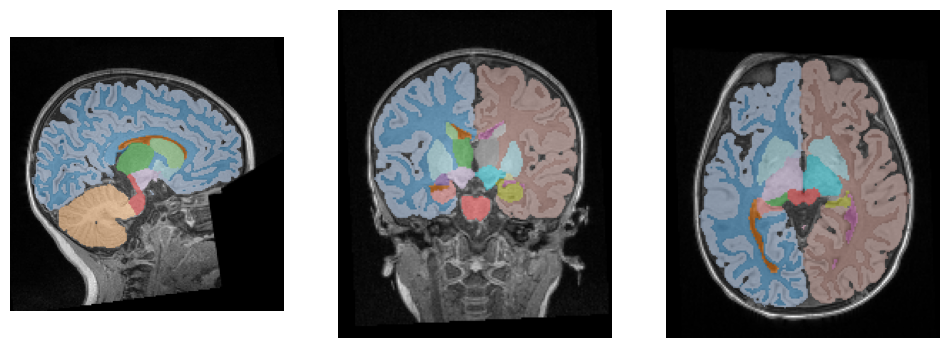

In [ ]:
# Load in image and segmentation
image = nib.load(str(mri_path)).get_fdata()
seg = nib.load(str(babyseg_path)).get_fdata()


# Generate the color map:
labels = np.unique(seg) 
label_map = {label: i for i, label in enumerate(labels)}
seg_mapped = np.vectorize(label_map.get)(seg)

# Find the midplane
x_mid,y_mid,z_mid = image.shape[0] // 2 -10, image.shape[1] // 2, image.shape[2] // 2

# plot the image
fig, axes = plt.subplots(ncols=3, figsize=(12, 12))


def overlay(ax, img_slice, seg_slice):

    # Show MRI scan
    ax.imshow(img_slice, cmap="gray")
    #  mask background so it doesn't wash out MRI
    seg_masked = np.ma.masked_where(seg_slice == 0, seg_slice)
    # plot masked segmentation
    ax.imshow(seg_masked,cmap="tab20",alpha=0.5)
    ax.axis("off")


overlay(axes[0], np.rot90(image[x_mid, :, :]), np.rot90(seg_mapped[x_mid, :, :]))
overlay(axes[1], np.rot90(image[:, y_mid, :]), np.rot90(seg_mapped[:, y_mid, :]))
overlay(axes[2], np.rot90(image[:, :, z_mid]), np.rot90(seg_mapped[:, :, z_mid]))
